In [211]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd 
dados = pd.read_csv('dados/car_data.csv')
dados.rename(columns = {'Purchased': 'Comprado', 'AnnualSalary': 'Salário Anual', 'Age': 'Idade', 'Gender': 'Genero', 'User ID': 'Usuario'}, inplace = True)

In [212]:
a_troca = {
    'Male': 'Masculino',
    'Female':'Feminino'
}
dados.Genero = dados.Genero.map(a_troca)

In [213]:
dados

,Usuario,Genero,Idade,Salário Anual,Comprado
0,385,Masculino,35,20000,0
1,681,Masculino,40,43500,0
2,353,Masculino,49,74000,0
3,895,Masculino,40,107500,1
4,661,Masculino,25,79000,0
...,...,...,...,...,...
995,863,Masculino,38,59000,0
996,800,Feminino,47,23500,0
997,407,Feminino,28,138500,1
998,299,Feminino,48,134000,1


In [214]:
dados.describe()

,Usuario,Idade,Salário Anual,Comprado
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,40.106000,72689.000000,0.402000
std,288.819436,10.707073,34488.341867,0.490547
min,1.000000,18.000000,15000.000000,0.000000
25%,250.750000,32.000000,46375.000000,0.000000
50%,500.500000,40.000000,72000.000000,0.000000
75%,750.250000,48.000000,90000.000000,1.000000
max,1000.000000,63.000000,152500.000000,1.000000


# Analisando Compras  

In [215]:
df1 = dados['Comprado'].value_counts().to_frame().reset_index()
df1.rename(columns = {'index': 'Vendido'}, inplace = True)
df1

,Vendido,Comprado
0,0,598
1,1,402


# Generos

# Box Plot
## Analisando Idades 

Text(0, 0.5, 'Idade')

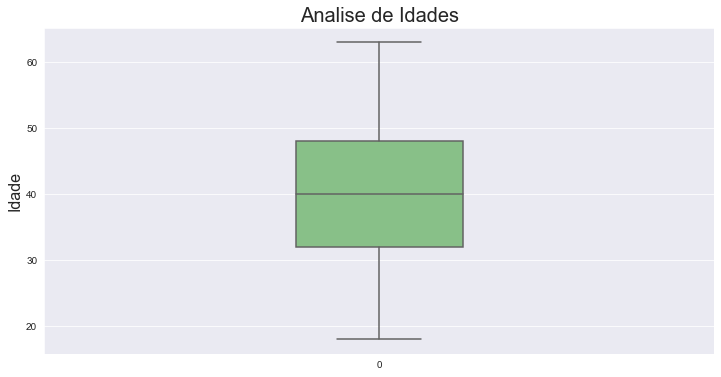

In [216]:
ax = sns.boxplot(data=dados['Idade'], orient = 'v', width= 0.25)

ax.figure.set_size_inches(12,6)
ax.set_title('Analise de Idades', fontsize=20)
ax.set_ylabel('Idade', fontsize=16)

In [217]:
sns.set_style('darkgrid')
sns.set_palette('Accent')

# Generos
## Comparando Salario Anual de Masculino e Feminino

Text(0, 0.5, 'Salario Anual')

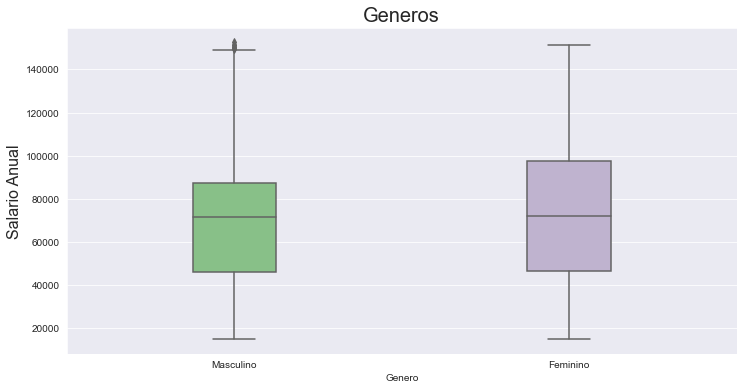

In [218]:
ax = sns.boxplot(x = 'Genero', y = 'Salário Anual', orient = 'v', width= 0.25, data=dados)

ax.figure.set_size_inches(12,6)
ax.set_title('Generos', fontsize=20)
ax.set_ylabel('Salario Anual', fontsize=16)

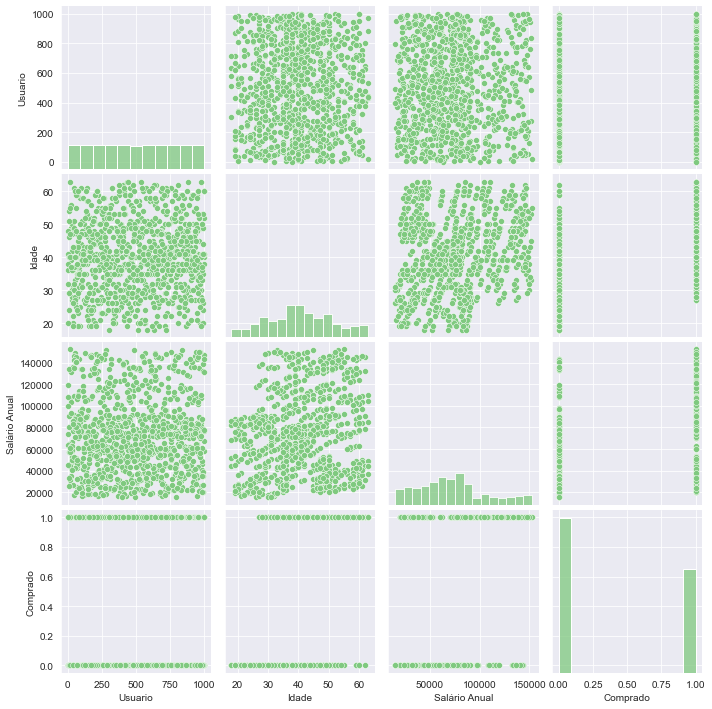

In [219]:
ax = sns.pairplot(dados)

In [220]:
df1 = (dados['Genero'] == 'Masculino') & (dados['Comprado'] == 1)
n1 = dados[df1]
n1

,Usuario,Genero,Idade,Salário Anual,Comprado
3,895,Masculino,40,107500,1
11,408,Masculino,47,23000,1
18,926,Masculino,46,79000,1
22,821,Masculino,54,25500,1
26,20,Masculino,40,107000,1
...,...,...,...,...,...
965,962,Masculino,52,150000,1
969,721,Masculino,29,148000,1
972,440,Masculino,63,85500,1
986,572,Masculino,48,33000,1


In [221]:
print('Idade Media {}'.format(n1.Idade.mean()))

Idade Media 47.21311475409836


## Total Vendido == Masculino

In [222]:
n1.Comprado.value_counts()

1    183
Name: Comprado, dtype: int64

In [223]:
df1 = (dados['Genero'] == 'Feminino') & (dados['Comprado'] == 1)
n2 = dados[df1]
n2

,Usuario,Genero,Idade,Salário Anual,Comprado
5,846,Feminino,47,33500,1
6,219,Feminino,46,132500,1
14,118,Feminino,42,108000,1
15,54,Feminino,33,149000,1
19,94,Feminino,39,134000,1
...,...,...,...,...,...
978,998,Feminino,60,77500,1
980,82,Feminino,46,23500,1
994,951,Feminino,53,104000,1
997,407,Feminino,28,138500,1


In [224]:
n2.Idade.mean()

48.926940639269404

## Total Vendido == Feminino

In [225]:
n2.Comprado.value_counts()

1    219
Name: Comprado, dtype: int64

In [226]:
dataset = dados.sort_values('Idade')
dataset.index = range(dataset.shape[0])
dataset

,Usuario,Genero,Idade,Salário Anual,Comprado
0,300,Feminino,18,68000,0
1,632,Feminino,18,86000,0
2,511,Feminino,18,44000,0
3,717,Masculino,18,82000,0
4,580,Masculino,18,52000,0
...,...,...,...,...,...
995,18,Masculino,63,44500,1
996,880,Masculino,63,36500,1
997,973,Feminino,63,110500,1
998,440,Masculino,63,85500,1


## Idade == 18 Anos não Fecharam 

In [227]:
df2 = (dataset['Idade'] == 18) & (dataset['Comprado'] ==0)
n3 = dataset[df2]
n3

,Usuario,Genero,Idade,Salário Anual,Comprado
0,300,Feminino,18,68000,0
1,632,Feminino,18,86000,0
2,511,Feminino,18,44000,0
3,717,Masculino,18,82000,0
4,580,Masculino,18,52000,0


## Total que não fecharam

In [228]:
df4 = (dados['Genero'] == 'Feminino') & (dados['Comprado'] == 0)
n5 = dados[df4]
n5

,Usuario,Genero,Idade,Salário Anual,Comprado
8,85,Feminino,30,84500,0
12,790,Feminino,32,72500,0
13,116,Feminino,27,57000,0
20,338,Feminino,39,51500,0
23,294,Feminino,41,61500,0
...,...,...,...,...,...
991,382,Feminino,30,48500,0
992,168,Feminino,24,67500,0
993,476,Feminino,54,136500,0
996,800,Feminino,47,23500,0


In [229]:
n5.Comprado.value_counts()

0    297
Name: Comprado, dtype: int64

In [230]:
df5 = (dados['Genero'] == 'Masculino') & (dados['Comprado'] == 0)
n6 = dados[df5]
n6.index = range(n6.shape[0])
n6

,Usuario,Genero,Idade,Salário Anual,Comprado
0,385,Masculino,35,20000,0
1,681,Masculino,40,43500,0
2,353,Masculino,49,74000,0
3,661,Masculino,25,79000,0
4,588,Masculino,42,64000,0
...,...,...,...,...,...
296,287,Masculino,32,59500,0
297,946,Masculino,39,60500,0
298,676,Masculino,42,54000,0
299,971,Masculino,25,56500,0


In [231]:
print('301 Masculino não fecharam')

301 Masculino não fecharam


In [232]:
troca_genero = {
    'Feminino': 0,
    'Masculino': 1 
}
dataset.Genero = dataset.Genero.map(troca_genero)
dataset

,Usuario,Genero,Idade,Salário Anual,Comprado
0,300,0,18,68000,0
1,632,0,18,86000,0
2,511,0,18,44000,0
3,717,1,18,82000,0
4,580,1,18,52000,0
...,...,...,...,...,...
995,18,1,63,44500,1
996,880,1,63,36500,1
997,973,0,63,110500,1
998,440,1,63,85500,1


# Masculino == 1 
# Feminino == 0

In [233]:
from sklearn.model_selection import train_test_split

In [234]:
x = dataset.drop('Comprado', axis = 1) # Vai treinar todos modelos, menos o Comprado.
y = dataset['Comprado'] # vai testar !

In [235]:
treino_x, teste_x, treino_y, teste_y = train_test_split(x, y, test_size = 0.3, random_state=33)

In [236]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [237]:
modelo = LinearRegression()

modelo.fit(treino_x, treino_y)


LinearRegression()

In [238]:
print('{}'.format(modelo.score(treino_x, treino_y).round(2)))

0.44


In [239]:
previsoes = modelo.predict(teste_x)

In [240]:
print('%s' % metrics.r2_score(teste_y, previsoes).round(2))

0.48


In [241]:
teste_x[0:1]

,Usuario,Genero,Idade,Salário Anual
286,308,1,35,50000


In [242]:
entrada = teste_x[0:1]
entrada

,Usuario,Genero,Idade,Salário Anual
286,308,1,35,50000


In [243]:
modelo.predict(entrada)[0].round(0)

0.0

In [244]:
entrada2 = teste_x[0:5]
entrada2

,Usuario,Genero,Idade,Salário Anual
286,308,1,35,50000
402,336,1,38,53500
253,754,0,33,69000
4,580,1,18,52000
372,528,0,37,64500


## Pessoas não fecharam!

In [245]:
modelo.predict(entrada2)[0].round(0)

0.0

## Total não vendido! 💰

In [253]:
dados['Comprado'].value_counts(normalize = True) *100


0    59.8
1    40.2
Name: Comprado, dtype: float64

In [254]:
print('59% Pessoas que não fecharam negocio')
print('40% Pessoas que fecharam negocio ')

59% Pessoas que não fecharam negocio
40% Pessoas que fecharam negocio 
